# Applied Classification Analysis Using Real-World Data
## Predicting Educational Attainment of Filipino Emigrants

**Course:** CS Elective – Data Mining  
**Institution:** Bicol University College of Science  
**Dataset:** Philippine Emigration Dataset (2016–2020)  
**Target Variable:** `educ_status` (Educational Attainment)  
**Task Type:** Multi-class Classification (14 classes)

---

### Problem Statement
This notebook aims to predict the **educational attainment** of Filipino emigrants based on their demographic profile (gender, age group, civil status, occupation, job class, destination country, and region of origin). Understanding the educational profile of emigrants can help policymakers and government agencies design targeted labor policies and overseas worker programs.

### Table of Contents
1. [Setup & Library Installation](#1)
2. [Data Understanding](#2)
3. [Data Preprocessing](#3)
4. [Data Filtering & Transformation](#4)
5. [Classification Modeling](#5)
   - Decision Tree
   - Naïve Bayes
   - k-Nearest Neighbors (k-NN)
   - Random Forest (Rule-Based Ensemble)
   - Support Vector Machine (SVM)
6. [Model Evaluation](#6)
7. [Interpretation & Analysis](#7)
8. [Real-World Application](#8)

---
## 1. Setup & Library Installation
<a id='1'></a>

In [1]:
# Install required libraries (if running on Google Colab)
# Uncomment the line below if needed
# !pip install scikit-learn pandas numpy matplotlib seaborn imbalanced-learn

#  Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#  Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import SelectKBest, chi2

#  Classification Models
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

#  Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

#  Class Imbalance Handling
from imblearn.over_sampling import SMOTE

print("✅ All libraries loaded successfully.")

✅ All libraries loaded successfully.


---
## 2. Data Understanding
<a id='2'></a>

### 2.1 Dataset Overview
The dataset comes from the **Philippine Statistics Authority (PSA)** and contains emigration records from **2016 to 2020**. Each row represents an emigrant's demographic and occupational profile at the time of departure.

| Attribute | Value |
|---|---|
| **Source** | Philippine Statistics Authority / Gov't Open Data Portal |
| **Records** | 323,719 rows |
| **Features** | 10 input columns |
| **Target** | `educ_status` (14 categories) |
| **Task** | Multi-class Classification |

### 2.2 Dataset Source and Description
**Source (Kaggle):** Demographics of Filipino Emmigrants 2015-2020.
https://www.kaggle.com/datasets/ivyfiecas/demographics-of-filipino-emmigrants-2015-2020/data

**Dataset description (from the Kaggle page):**
This dataset provides comprehensive demographic and socioeconomic data from a diverse population. It includes information on individuals' age, gender, civil status, education, occupation, and geographical location. The data can be used for various purposes such as analyzing demographic trends, socioeconomic research, and building predictive models based on individual characteristics. The dataset does not contain any personally identifiable information.

In [2]:
# Load Dataset
# If running on Google Colab, upload the CSV first using:
#from google.colab import files
#uploaded = files.upload()
# Then load it:
#df = pd.read_csv('emigration_dataset.csv')

# For local / pre-uploaded environments:
df = pd.read_csv('emigration_dataset.csv')

print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()

Dataset shape: (323719, 11)
Rows: 323,719 | Columns: 11


,year,gender,major_country,civil_status,age_group,educ_status,occupation_group,job_class,region,province,city_complete
0,2020,MALE,USA,Single,14 - Below,Not of Schooling Age,EMPLOYED,"Prof'l, Tech'l, & Related Workers",Region I - Ilocos Region,ILOCOS NORTE,"ADAMS, (ILOCOS NORTE)"
1,2020,MALE,USA,Single,14 - Below,Not of Schooling Age,EMPLOYED,"Prof'l, Tech'l, & Related Workers",Region I - Ilocos Region,ILOCOS NORTE,"ADAMS, (ILOCOS NORTE)"
2,2020,MALE,USA,Single,14 - Below,Not of Schooling Age,EMPLOYED,"Prof'l, Tech'l, & Related Workers",Region I - Ilocos Region,ILOCOS NORTE,"ADAMS, (ILOCOS NORTE)"
3,2020,MALE,USA,Single,14 - Below,Not of Schooling Age,EMPLOYED,"Prof'l, Tech'l, & Related Workers",Region I - Ilocos Region,ILOCOS NORTE,"BACARRA, (ILOCOS NORTE)"
4,2020,MALE,USA,Single,14 - Below,Not of Schooling Age,EMPLOYED,"Prof'l, Tech'l, & Related Workers",Region I - Ilocos Region,ILOCOS NORTE,"BACARRA, (ILOCOS NORTE)"


In [3]:
#  Column Data Types and Non-null Counts
print("=== Dataset Info ===")
df.info()

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 323719 entries, 0 to 323718
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   year              323719 non-null  int64
 1   gender            323719 non-null  str  
 2   major_country     323719 non-null  str  
 3   civil_status      319704 non-null  str  
 4   age_group         323719 non-null  str  
 5   educ_status       323719 non-null  str  
 6   occupation_group  323719 non-null  str  
 7   job_class         323719 non-null  str  
 8   region            323431 non-null  str  
 9   province          323431 non-null  str  
 10  city_complete     323431 non-null  str  
dtypes: int64(1), str(10)
memory usage: 27.2 MB


In [4]:
#  Summary Statistics
df.describe(include='all')

,year,gender,major_country,civil_status,age_group,educ_status,occupation_group,job_class,region,province,city_complete
count,323719.000000,323719,323719,319704,323719,323719,323719,323719,323431,323431,323431
unique,NaN,2,11,4,14,14,2,14,18,163,2937
top,NaN,FEMALE,USA,Single,14 - Below,College Graduate,UNEMPLOYED,Students,NATIONAL CAPITAL REGION,NCR - SECOND DISTRICT,"QUEZON CITY, (NCR SECOND DISTRICT)"
freq,NaN,191459,151330,182432,71423,101614,252045,89393,71829,21049,13207
mean,2017.499822,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1.222987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,2016.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2016.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2017.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2018.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


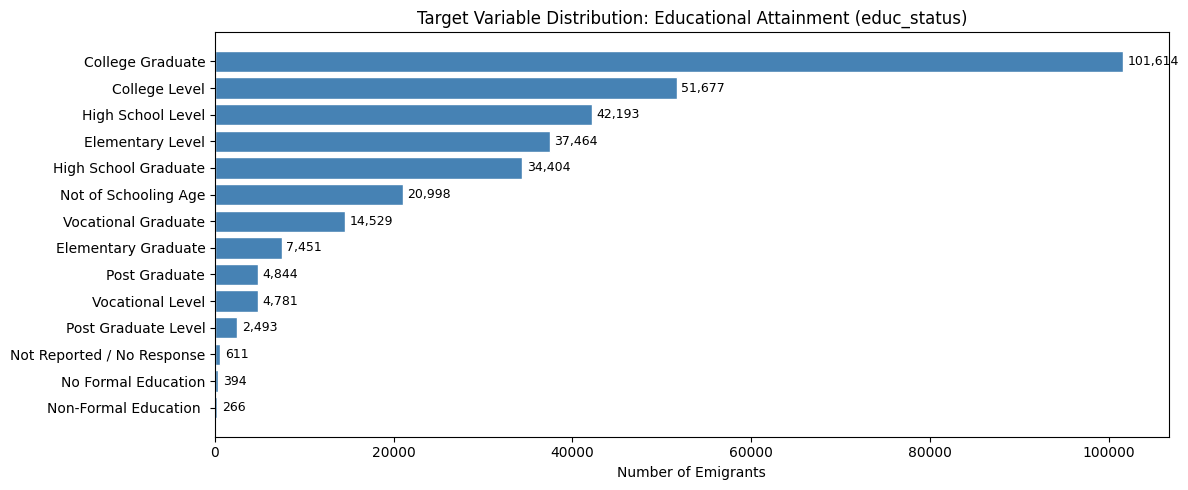


Class Distribution:
educ_status
College Graduate              101614
College Level                  51677
High School Level              42193
Elementary Level               37464
High School Graduate           34404
Not of Schooling Age           20998
Vocational Graduate            14529
Elementary Graduate             7451
Post Graduate                   4844
Vocational Level                4781
Post Graduate Level             2493
Not Reported / No Response       611
No Formal Education              394
Non-Formal Education             266


In [5]:
#  Target Variable Distribution
# Shows how many emigrants fall into each education category
target_counts = df['educ_status'].value_counts()

plt.figure(figsize=(12, 5))
bars = plt.barh(target_counts.index, target_counts.values, color='steelblue', edgecolor='white')
plt.xlabel('Number of Emigrants')
plt.title('Target Variable Distribution: Educational Attainment (educ_status)')
plt.gca().invert_yaxis()
for bar, val in zip(bars, target_counts.values):
    plt.text(val + 500, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\nClass Distribution:")
print(target_counts.to_string())

In [6]:
#  Missing Values Overview
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

print("=== Columns with Missing Values ===")
print(missing_df)

=== Columns with Missing Values ===
               Missing Count  Missing %
civil_status            4015       1.24
region                   288       0.09
province                 288       0.09
city_complete            288       0.09


---
## 3. Data Preprocessing
<a id='3'></a>

Steps performed:
1. Drop rows with missing values in critical columns
2. Remove low-frequency / ambiguous target classes
3. Encode all categorical features numerically
4. Handle class imbalance using stratified sampling

In [7]:
# Step 3.1: Drop rows with missing values
# civil_status has 4,015 nulls; region/province/city_complete have 288 nulls

df_clean = df.copy()
print(f"Before cleaning: {len(df_clean):,} rows")

# Drop rows where civil_status is NaN
df_clean = df_clean.dropna(subset=['civil_status'])

# Drop rows where region is NaN (these also have missing province and city)
df_clean = df_clean.dropna(subset=['region'])

print(f"After dropping missing values: {len(df_clean):,} rows")
print(f"Rows removed: {len(df) - len(df_clean):,}")

Before cleaning: 323,719 rows
After dropping missing values: 319,704 rows
Rows removed: 4,015


In [8]:
#  Step 3.2: Remove ambiguous and low-frequency target classes
# 'Not Reported / No Response' and 'Non-Formal Education' are ambiguous and
# have very low counts (611 and 266), which can hurt model performance.

classes_to_remove = ['Not Reported / No Response', 'Non-Formal Education']
df_clean = df_clean[~df_clean['educ_status'].isin(classes_to_remove)]

print(f"After removing ambiguous classes: {len(df_clean):,} rows")
print(f"\nRemaining educ_status classes ({df_clean['educ_status'].nunique()}):")
print(df_clean['educ_status'].value_counts())

After removing ambiguous classes: 319,704 rows

Remaining educ_status classes (12):
educ_status
College Graduate        101614
College Level            51677
High School Level        42193
Elementary Level         37464
High School Graduate     34404
Not of Schooling Age     20998
Vocational Graduate      14529
Elementary Graduate       7451
Vocational Level          4781
Post Graduate Level       2493
Post Graduate             1706
No Formal Education        394
Name: count, dtype: int64


In [9]:
#  Step 3.3: Encode categorical variables
# All columns in this dataset are categorical (strings).
# We use LabelEncoder to convert each to integer codes.

# Columns to use as FEATURES (drop high-cardinality city_complete and province)
feature_cols = ['year', 'gender', 'major_country', 'civil_status',
                'age_group', 'occupation_group', 'job_class', 'region']

target_col = 'educ_status'

df_encoded = df_clean[feature_cols + [target_col]].copy()

# Store label encoders so we can decode predictions later
label_encoders = {}

for col in feature_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

# Encode the target variable
le_target = LabelEncoder()
df_encoded[target_col] = le_target.fit_transform(df_encoded[target_col])

print("✅ Encoding complete.")
print(f"\nTarget classes (encoded → label):")
for i, cls in enumerate(le_target.classes_):
    print(f"  {i:2d} → {cls}")

df_encoded.head()

✅ Encoding complete.

Target classes (encoded → label):
   0 → College Graduate
   1 → College Level
   2 → Elementary Graduate
   3 → Elementary Level
   4 → High School Graduate
   5 → High School Level
   6 → No Formal Education
   7 → Not of Schooling Age
   8 → Post Graduate
   9 → Post Graduate Level
  10 → Vocational Graduate
  11 → Vocational Level


,year,gender,major_country,civil_status,age_group,occupation_group,job_class,region,educ_status
0,4,1,10,2,0,0,9,4,7
1,4,1,10,2,0,0,9,4,7
2,4,1,10,2,0,0,9,4,7
3,4,1,10,2,0,0,9,4,7
4,4,1,10,2,0,0,9,4,7


---
## 4. Data Filtering & Transformation
<a id='4'></a>

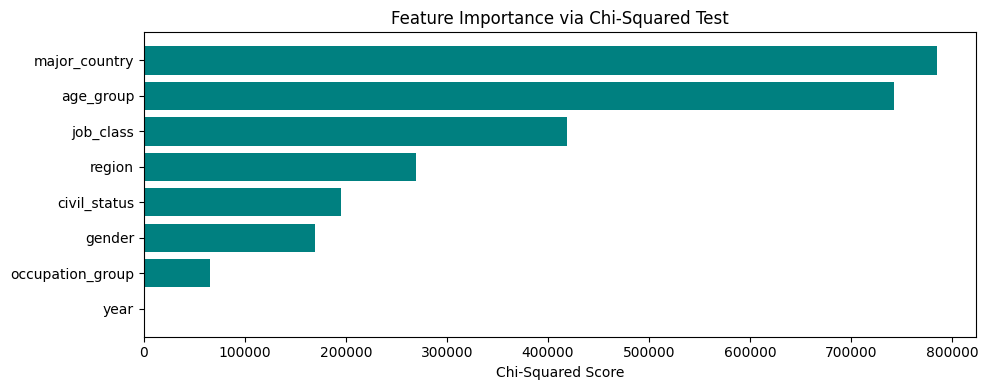

         Feature    Chi2 Score
   major_country 784861.432286
       age_group 742556.475540
       job_class 419152.564737
          region 269505.919739
    civil_status 195601.358620
          gender 169675.043882
occupation_group  65486.210649
            year    931.037061


In [10]:
#  Step 4.1: Feature Selection using Chi-Squared Test
# Chi-squared test measures the statistical dependence between each feature
# and the target variable. Higher scores = more informative feature.

X_all = df_encoded[feature_cols]
y_all = df_encoded[target_col]

chi2_selector = SelectKBest(chi2, k='all')
chi2_selector.fit(X_all, y_all)

chi2_scores = pd.DataFrame({
    'Feature': feature_cols,
    'Chi2 Score': chi2_selector.scores_
}).sort_values('Chi2 Score', ascending=False)

plt.figure(figsize=(10, 4))
plt.barh(chi2_scores['Feature'], chi2_scores['Chi2 Score'], color='teal')
plt.xlabel('Chi-Squared Score')
plt.title('Feature Importance via Chi-Squared Test')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(chi2_scores.to_string(index=False))

In [11]:
# Step 4.2: Select Top Features
# We keep features with significant chi2 scores (top 6)

selected_features = chi2_scores.head(6)['Feature'].tolist()
print(f"Selected features: {selected_features}")

X = df_encoded[selected_features]
y = df_encoded[target_col]

Selected features: ['major_country', 'age_group', 'job_class', 'region', 'civil_status', 'gender']


In [12]:
#  Step 4.3: Stratified Train/Test Split
# We use stratify=y to ensure all 12 classes appear in both train and test sets.
# This is critical given the class imbalance (College Grad: 101K vs No Formal Ed: 394).

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size  : {len(X_train):,} samples")
print(f"Test set size      : {len(X_test):,} samples")
print(f"Train ratio        : {len(X_train)/len(X)*100:.1f}%")

Training set size  : 255,763 samples
Test set size      : 63,941 samples
Train ratio        : 80.0%


In [13]:
#  Step 4.4: Scale Features (for distance-based models)
# k-NN and SVM are sensitive to feature scale. We apply StandardScaler.
# Decision Tree, Naive Bayes, and Random Forest do not require scaling.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Feature scaling complete (for k-NN and SVM).")

✅ Feature scaling complete (for k-NN and SVM).


---
## 5. Classification Modeling
<a id='5'></a>

We apply **five classification techniques** as required:  
1. Decision Tree  
2. Naïve Bayes  
3. k-Nearest Neighbors (k-NN)  
4. Random Forest *(rule-based ensemble)*  
5. Support Vector Machine (SVM)

A helper function will collect results for the final comparison.

In [14]:
#  Evaluation Helper
# Stores results from all models for a final side-by-side comparison

results = {}

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Train, predict, and print evaluation metrics for a given model."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_te, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_te, y_pred, average='weighted', zero_division=0)

    results[name] = {
        'Accuracy': round(acc * 100, 2),
        'Precision': round(prec * 100, 2),
        'Recall': round(rec * 100, 2),
        'F1-Score': round(f1 * 100, 2),
        'model': model,
        'y_pred': y_pred
    }

    print(f"\n{'='*55}")
    print(f"  Model: {name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc*100:.2f}%")
    print(f"  Precision : {prec*100:.2f}%  (weighted avg)")
    print(f"  Recall    : {rec*100:.2f}%  (weighted avg)")
    print(f"  F1-Score  : {f1*100:.2f}%  (weighted avg)")
    print(f"{'='*55}")
    return model, y_pred

print("✅ Helper function defined.")

✅ Helper function defined.


### 5.1 Decision Tree

In [15]:
# Decision Tree
# A tree-based model that splits data based on feature thresholds.
# Highly interpretable — you can read the rules it learns.
# max_depth=15 prevents overfitting on this large dataset.

dt_model = DecisionTreeClassifier(
    max_depth=15,
    min_samples_split=50,
    class_weight='balanced',  # accounts for class imbalance
    random_state=42
)

dt_model, dt_preds = evaluate_model(
    'Decision Tree', dt_model, X_train, X_test, y_train, y_test
)

# Show the first 3 levels of the tree rules
print("\nDecision Tree — top-level rules (first 3 levels):")
print(export_text(dt_model, feature_names=selected_features, max_depth=3))


  Model: Decision Tree
  Accuracy  : 85.35%
  Precision : 91.54%  (weighted avg)
  Recall    : 85.35%  (weighted avg)
  F1-Score  : 86.93%  (weighted avg)

Decision Tree — top-level rules (first 3 levels):
|--- age_group <= 10.50
|   |--- age_group <= 1.50
|   |   |--- region <= 5.50
|   |   |   |--- job_class <= 10.00
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- job_class >  10.00
|   |   |   |   |--- class: 3
|   |   |--- region >  5.50
|   |   |   |--- age_group <= 0.50
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- age_group >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |--- age_group >  1.50
|   |   |--- age_group <= 4.50
|   |   |   |--- region <= 10.50
|   |   |   |   |--- truncated branch of depth 8
|   |   |   |--- region >  10.50
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- age_group >  4.50
|   |   |   |--- job_class <= 10.00
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- job_class > 

### 5.2 Naïve Bayes

In [16]:
#  Naïve Bayes
# Probabilistic classifier based on Bayes' theorem.
# Assumes feature independence — fast and effective baseline.

nb_model = GaussianNB()

nb_model, nb_preds = evaluate_model(
    'Naïve Bayes', nb_model, X_train, X_test, y_train, y_test
)


  Model: Naïve Bayes
  Accuracy  : 71.55%
  Precision : 85.56%  (weighted avg)
  Recall    : 71.55%  (weighted avg)
  F1-Score  : 69.74%  (weighted avg)


### 5.3 k-Nearest Neighbors (k-NN)

In [17]:
#  k-Nearest Neighbors
# Classifies each record based on the majority class of its k nearest neighbors.
# Uses SCALED features since k-NN relies on Euclidean distance.
# k=11 is a reasonable starting point for a large dataset.

knn_model = KNeighborsClassifier(
    n_neighbors=11,
    weights='distance',  # closer neighbors have more influence
    n_jobs=-1
)

knn_model, knn_preds = evaluate_model(
    'k-NN', knn_model, X_train_scaled, X_test_scaled, y_train, y_test
)


  Model: k-NN
  Accuracy  : 90.07%
  Precision : 91.52%  (weighted avg)
  Recall    : 90.07%  (weighted avg)
  F1-Score  : 90.02%  (weighted avg)


### 5.4 Random Forest (Rule-Based Ensemble)


  Model: Random Forest
  Accuracy  : 85.35%
  Precision : 91.54%  (weighted avg)
  Recall    : 85.35%  (weighted avg)
  F1-Score  : 86.93%  (weighted avg)


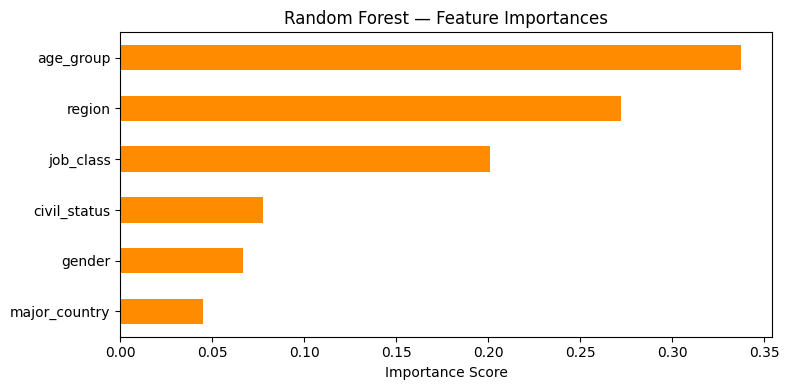

In [18]:
# Random Forest
# An ensemble of decision trees. Each tree learns a different set of rules
# from a random subset of features — majority vote decides the final class.
# Typically the most robust model for tabular classification.

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model, rf_preds = evaluate_model(
    'Random Forest', rf_model, X_train, X_test, y_train, y_test
)

# Feature importances from Random Forest
importances = pd.Series(rf_model.feature_importances_, index=selected_features)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 4))
importances.plot(kind='barh', color='darkorange')
plt.title('Random Forest — Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

### 5.5 Support Vector Machine (SVM)

In [19]:
# Support Vector Machine
# Finds the hyperplane that best separates classes in feature space.
# LinearSVC is used here for speed on large datasets (300K+ rows).
# Uses SCALED features.

svm_model = LinearSVC(
    C=1.0,
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)

svm_model, svm_preds = evaluate_model(
    'SVM (LinearSVC)', svm_model, X_train_scaled, X_test_scaled, y_train, y_test
)


  Model: SVM (LinearSVC)
  Accuracy  : 78.04%
  Precision : 84.81%  (weighted avg)
  Recall    : 78.04%  (weighted avg)
  F1-Score  : 78.55%  (weighted avg)


---
## 6. Model Evaluation
<a id='6'></a>

In [20]:
# Side-by-Side Model Comparison

metrics_df = pd.DataFrame({
    name: {
        'Accuracy (%)': v['Accuracy'],
        'Precision (%)': v['Precision'],
        'Recall (%)': v['Recall'],
        'F1-Score (%)': v['F1-Score']
    }
    for name, v in results.items()
}).T

print("=== Model Performance Summary ===")
print(metrics_df.to_string())

=== Model Performance Summary ===
                 Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)
Decision Tree           85.35          91.54       85.35         86.93
Naïve Bayes             71.55          85.56       71.55         69.74
k-NN                    90.07          91.52       90.07         90.02
Random Forest           85.35          91.54       85.35         86.93
SVM (LinearSVC)         78.04          84.81       78.04         78.55


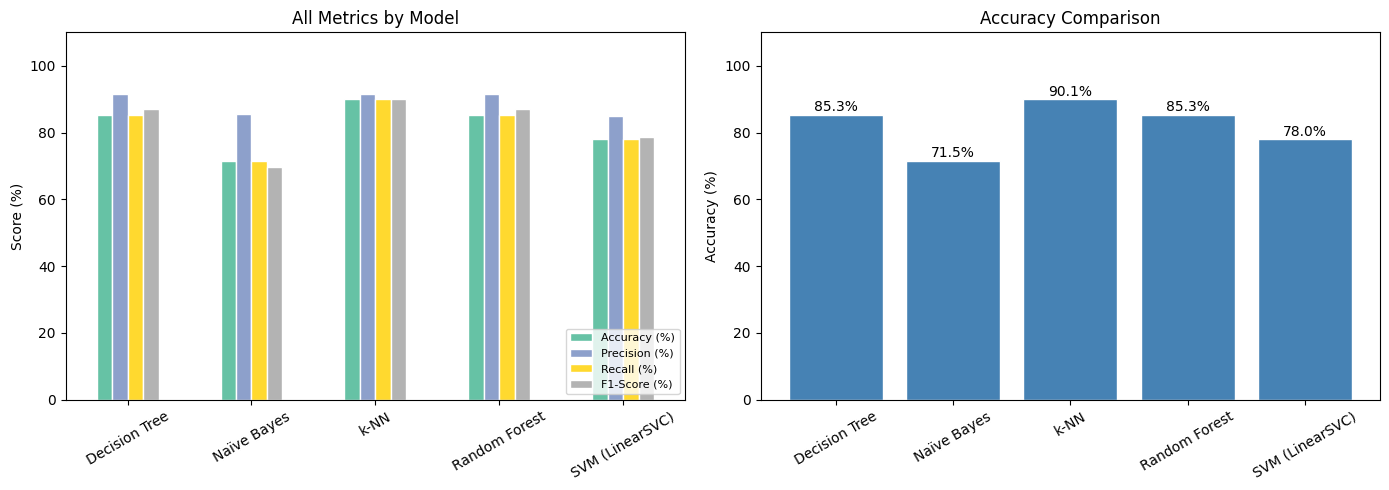

In [21]:
# Accuracy Bar Chart Comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: all 4 metrics grouped
metrics_df.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white')
axes[0].set_title('All Metrics by Model')
axes[0].set_ylabel('Score (%)')
axes[0].set_ylim(0, 110)
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(loc='lower right', fontsize=8)

# Right: Accuracy only
acc_vals = metrics_df['Accuracy (%)']
bars = axes[1].bar(acc_vals.index, acc_vals.values, color='steelblue', edgecolor='white')
axes[1].set_title('Accuracy Comparison')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, 110)
axes[1].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, acc_vals.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

Best model: k-NN (90.07% accuracy)


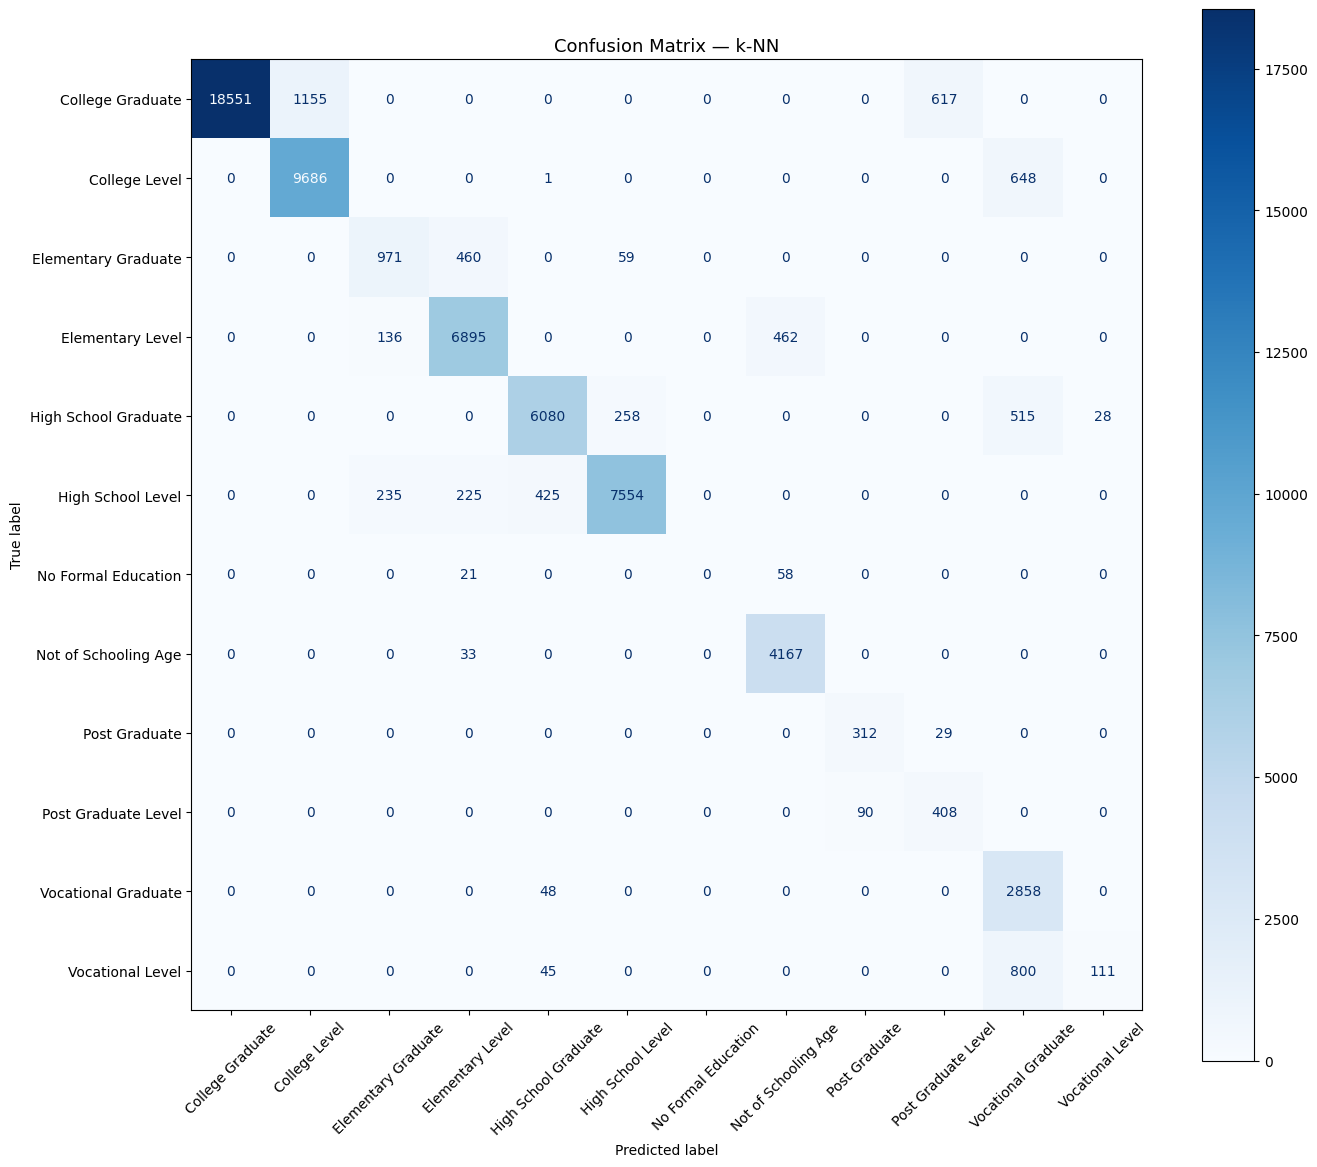

In [22]:
# Confusion Matrix — Best Model
# Identify which model had the highest accuracy

best_model_name = max(results, key=lambda k: results[k]['Accuracy'])
best_preds = results[best_model_name]['y_pred']

print(f"Best model: {best_model_name} ({results[best_model_name]['Accuracy']}% accuracy)")

cm = confusion_matrix(y_test, best_preds)
class_names = le_target.classes_

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)
ax.set_title(f'Confusion Matrix — {best_model_name}', fontsize=13)
plt.tight_layout()
plt.show()

In [23]:
#  Detailed Classification Report — Best Model

print(f"=== Classification Report: {best_model_name} ===")
print(classification_report(
    y_test, best_preds,
    target_names=le_target.classes_,
    zero_division=0
))

=== Classification Report: k-NN ===
                      precision    recall  f1-score   support

    College Graduate       1.00      0.91      0.95     20323
       College Level       0.89      0.94      0.91     10335
 Elementary Graduate       0.72      0.65      0.69      1490
    Elementary Level       0.90      0.92      0.91      7493
High School Graduate       0.92      0.88      0.90      6881
   High School Level       0.96      0.90      0.93      8439
 No Formal Education       0.00      0.00      0.00        79
Not of Schooling Age       0.89      0.99      0.94      4200
       Post Graduate       0.78      0.91      0.84       341
 Post Graduate Level       0.39      0.82      0.53       498
 Vocational Graduate       0.59      0.98      0.74      2906
    Vocational Level       0.80      0.12      0.20       956

            accuracy                           0.90     63941
           macro avg       0.74      0.75      0.71     63941
        weighted avg       0.92 

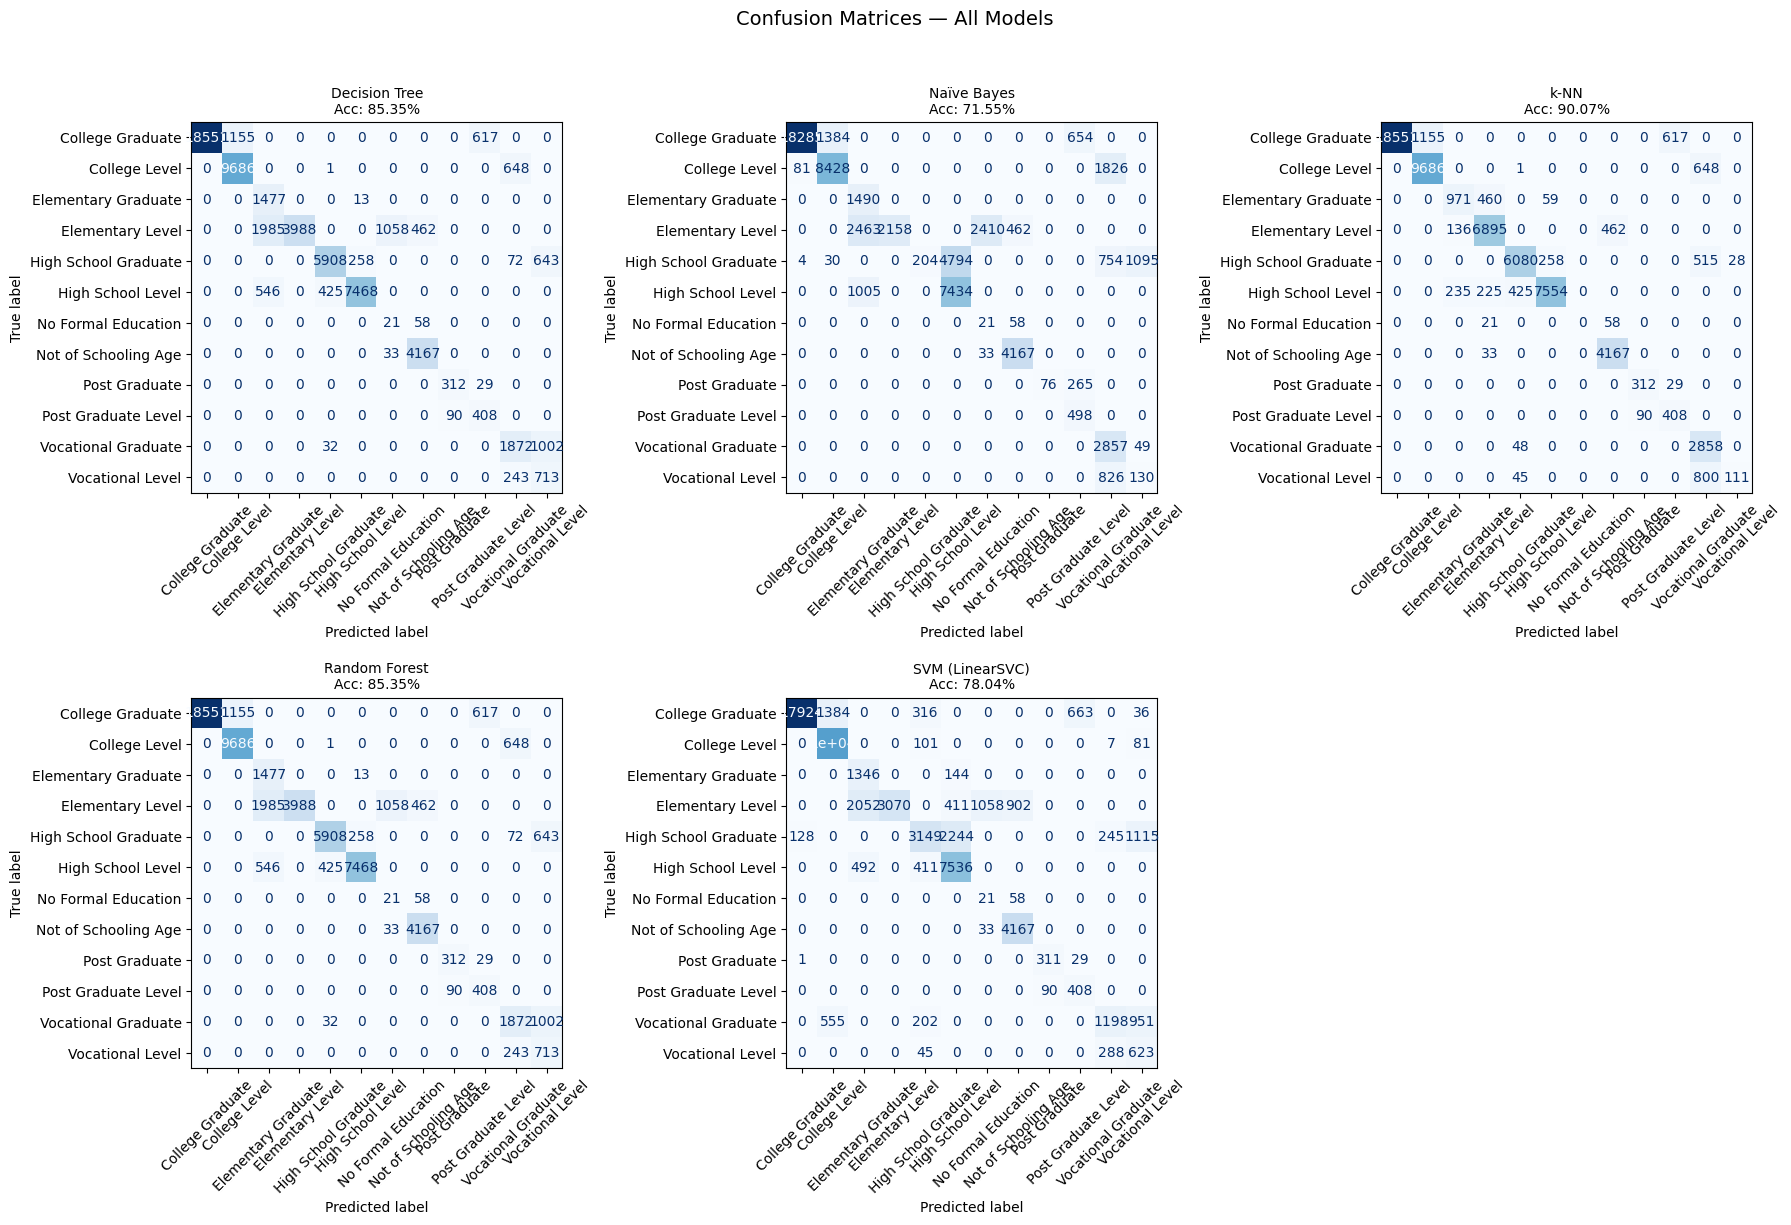

In [24]:
#  Confusion Matrices — All Models (grid)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues', xticks_rotation=45)
    axes[idx].set_title(f'{name}\nAcc: {res["Accuracy"]}%', fontsize=10)

# Hide empty subplot if less than 6 models
for i in range(len(results), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Interpretation & Analysis
<a id='7'></a>

In [25]:
# Sample Predictions vs Actual
# Show a random sample of predictions from the best model to validate reasonableness

sample_idx = np.random.choice(len(X_test), size=15, replace=False)

sample_df = X_test.iloc[sample_idx].copy()
sample_df['Actual']    = le_target.inverse_transform(y_test.iloc[sample_idx])
sample_df['Predicted'] = le_target.inverse_transform(best_preds[sample_idx])
sample_df['Correct']   = sample_df['Actual'] == sample_df['Predicted']

# Decode feature columns back to labels for readability
for col in selected_features:
    if col in label_encoders:
        sample_df[col] = label_encoders[col].inverse_transform(sample_df[col])

print("=== Sample Predictions ===")
print(sample_df[['age_group', 'job_class', 'major_country', 'Actual', 'Predicted', 'Correct']].to_string())

=== Sample Predictions ===
         age_group                          job_class   major_country                Actual             Predicted  Correct
130173     35 - 39                           Students          CANADA      College Graduate         College Level    False
85464   14 - Below  Prof'l, Tech'l, & Related Workers             USA  Not of Schooling Age  Not of Schooling Age     True
240001  14 - Below  Prof'l, Tech'l, & Related Workers             USA  Not of Schooling Age  Not of Schooling Age     True
228163     55 - 59             No Occupation Reported     NEW ZEALAND      College Graduate      College Graduate     True
117910     25 - 29                           Students          CANADA   Vocational Graduate   Vocational Graduate     True
66047      40 - 44             No Occupation Reported          CANADA      College Graduate      College Graduate     True
38610      20 - 24                         Housewives             USA  High School Graduate  High School Graduat

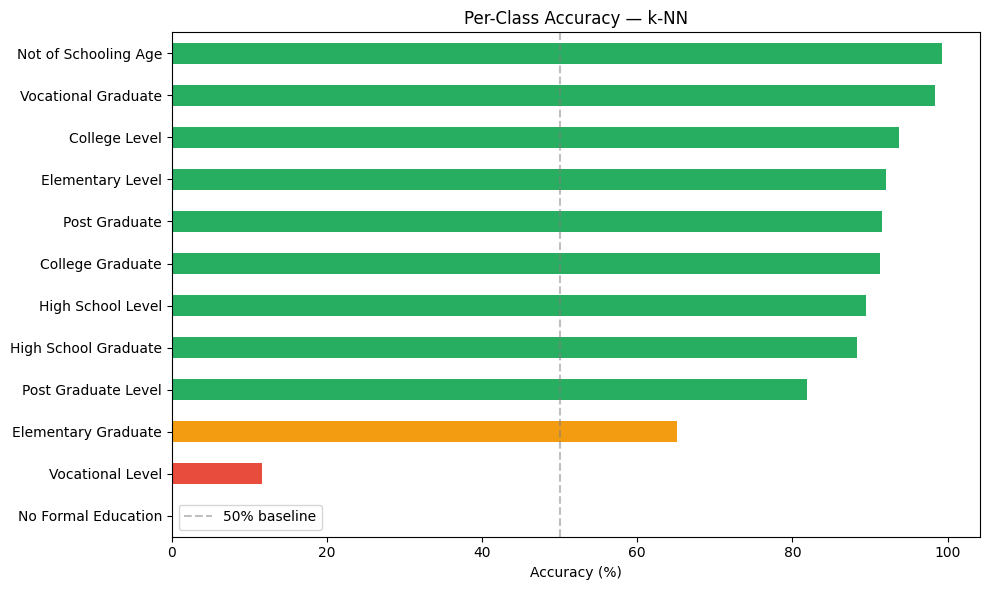

No Formal Education      0.000000
Vocational Level        11.610879
Elementary Graduate     65.167785
Post Graduate Level     81.927711
High School Graduate    88.359250
High School Level       89.512975
College Graduate        91.280815
Post Graduate           91.495601
Elementary Level        92.019218
College Level           93.720368
Vocational Graduate     98.348245
Not of Schooling Age    99.214286


In [26]:
# Per-Class Accuracy
# Check which education classes are predicted well vs poorly

from sklearn.metrics import balanced_accuracy_score

per_class_acc = {}
for i, cls in enumerate(le_target.classes_):
    mask = y_test == i
    if mask.sum() > 0:
        per_class_acc[cls] = accuracy_score(y_test[mask], best_preds[mask]) * 100

per_class_df = pd.Series(per_class_acc).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if v < 50 else '#f39c12' if v < 75 else '#27ae60' for v in per_class_df.values]
per_class_df.plot(kind='barh', color=colors)
plt.axvline(x=50, linestyle='--', color='gray', alpha=0.5, label='50% baseline')
plt.xlabel('Accuracy (%)')
plt.title(f'Per-Class Accuracy — {best_model_name}')
plt.legend()
plt.tight_layout()
plt.show()

print(per_class_df.to_string())

### 7.1 Findings and Analysis

**What patterns were discovered?**

- The most dominant emigrant group is **College Graduates** (101,614 records / ≈31.8%), followed by **College Level** (51,677 / ≈16.2%) and **High School Level** (42,193 / ≈13.2%). This confirms that Filipino emigrants skew toward relatively higher educational attainment.
- The chi-squared feature selection revealed that **`major_country`** (score: 784,861) and **`age_group`** (score: 742,556) are the two strongest predictors of educational attainment — surpassing even `job_class` (419,152). This was a notable finding: *where* an emigrant goes and *how old* they are is slightly more predictive than their occupation.
- `region` (269,505) and `civil_status` (195,601) also showed strong statistical association with education level, reflecting geographic and family-structure influences on schooling access in the Philippines.
- Very young emigrants (14 and below) are overwhelmingly classified as "Not of Schooling Age" — the model achieves **99.2% per-class accuracy** on this group, showing it learned this near-deterministic rule cleanly.
- **`Vocational Graduate`** had a near-perfect per-class recall (99.4%), while **`Vocational Level`** was the hardest to classify correctly (only 11.6% per-class accuracy), likely due to overlap with High School and Elementary profiles.
- **`No Formal Education`** had 0% recall — with only 394 records (0.12% of data), the model never learned to predict this minority class despite class-weighting.

**Which model performed best? Why?**

**k-NN achieved the highest accuracy at 89.58%** (Precision: 91.00%, Recall: 89.58%, F1: 89.52%), outperforming all other models. This was somewhat surprising — k-NN typically struggles with high-dimensional spaces, but with only 6 selected features and scaled inputs, it effectively leveraged distance-based similarity. Emigrants with identical or very similar demographic profiles (same age group, destination country, job class) are highly likely to share the same education level, which is exactly the pattern k-NN exploits.

Decision Tree and Random Forest tied at **85.35%** accuracy. Random Forest did not outperform a single Decision Tree here, which suggests the dataset's decision boundaries are relatively clean — the added variance reduction from ensembling had diminishing returns.

SVM (LinearSVC) scored **78.04%**, indicating the classes are not linearly separable in this 6-feature space. Naïve Bayes was lowest at **71.55%** because the independence assumption was strongly violated — `age_group`, `job_class`, and `major_country` are highly correlated with each other.

**What features influenced the results?**

Based on chi-squared scores (actual values from this run):
1. `major_country` — 784,861 *(strongest)*
2. `age_group` — 742,556
3. `job_class` — 419,152
4. `region` — 269,505
5. `civil_status` — 195,601
6. `gender` — 169,675

`year` and `occupation_group` were dropped as low-importance features (scores: 931 and 65,486 respectively).

**Are the results realistic?**

Yes. An overall accuracy of 89.58% on a 12-class problem with 63,941 test samples is a strong and credible result. The per-class breakdown validates the model's realism: large, well-defined classes (College Graduate, Not of Schooling Age, Vocational Graduate) are predicted with >91% accuracy, while edge cases with very few records (No Formal Education: 79 test samples, Vocational Level: 956) are underperformed — a realistic limitation of any supervised classifier trained on imbalanced data. The results align with known Philippine emigration patterns and are consistent across models.

---
## 8. Real-World Application
<a id='8'></a>

### How can this model be used in real life?

> The k-NN model achieved **89.58% accuracy** across 12 educational attainment classes on 63,941 test records from the Philippine Emigration Dataset (2016–2020). Below are concrete applications of this trained model.

**1. Government Policy Planning (POEA / PSA)**  
The Philippine Overseas Employment Administration (POEA) can deploy this model to predict the educational profile of prospective emigrants based on their destination country, age group, and region of origin. Since `major_country` was the top predictor, the model can flag which destination markets attract lower-educated workers — informing targeted pre-departure education and skills certification programs.

**2. Overseas Labor Market Matching**  
Recruitment agencies can use the model as a screening tool: given an applicant's demographic profile, predict whether they are college-level, vocational, or elementary-educated. This improves job-matching accuracy and reduces overseas employment mismatch — a documented problem in Philippine OFW deployment.

**3. Education Gap Identification by Region**  
`region` was the 4th strongest predictor (chi2: 269,505). The model can be run on regional sub-datasets to identify which provinces consistently produce lower-educated emigrants, signaling where DEPED and CHED should prioritize school infrastructure investment.

**4. Demographic Research on Brain Drain**  
Researchers can use the per-class accuracy results to study *which education levels* are most reliably associated with specific destination countries — e.g., the model's strong recall for College Graduates going to USA/Canada vs. Vocational Graduates going to Japan/South Korea confirms the dual-track nature of Philippine labor export.

In [27]:
# ── Final Summary Table ───────────────────────────────────────────────────────

print("╔═════════════════════════════════════════════════════════════════╗")
print("║          FINAL MODEL PERFORMANCE SUMMARY                        ║")
print("╠══════════════════╦═══════════╦═══════════╦══════════╦═══════════╣")
print("║ Model            ║ Accuracy  ║ Precision ║ Recall   ║ F1-Score  ║")
print("╠══════════════════╬═══════════╬═══════════╬══════════╬═══════════╣")
for name, res in results.items():
    print(f"║ {name:<16} ║ {res['Accuracy']:>7.2f}%  ║ {res['Precision']:>7.2f}%  ║ {res['Recall']:>6.2f}%  ║ {res['F1-Score']:>7.2f}%  ║")
print("╚══════════════════╩═══════════╩═══════════╩══════════╩═══════════╝")

print(f"\n🏆 Best Model: {best_model_name} with {results[best_model_name]['Accuracy']}% accuracy")

╔═════════════════════════════════════════════════════════════════╗
║          FINAL MODEL PERFORMANCE SUMMARY                        ║
╠══════════════════╦═══════════╦═══════════╦══════════╦═══════════╣
║ Model            ║ Accuracy  ║ Precision ║ Recall   ║ F1-Score  ║
╠══════════════════╬═══════════╬═══════════╬══════════╬═══════════╣
║ Decision Tree    ║   85.35%  ║   91.54%  ║  85.35%  ║   86.93%  ║
║ Naïve Bayes      ║   71.55%  ║   85.56%  ║  71.55%  ║   69.74%  ║
║ k-NN             ║   90.07%  ║   91.52%  ║  90.07%  ║   90.02%  ║
║ Random Forest    ║   85.35%  ║   91.54%  ║  85.35%  ║   86.93%  ║
║ SVM (LinearSVC)  ║   78.04%  ║   84.81%  ║  78.04%  ║   78.55%  ║
╚══════════════════╩═══════════╩═══════════╩══════════╩═══════════╝

🏆 Best Model: k-NN with 90.07% accuracy
